In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv

In [2]:
def read_file(file):
    x = []
    y = []
    with open(file,'r') as csvfile:
        plots = csv.reader(csvfile, delimiter = ',')
        for row in plots:
            x.append(float(row[0]))
            y.append(float(row[1]))
    return np.array(x), np.array(y)

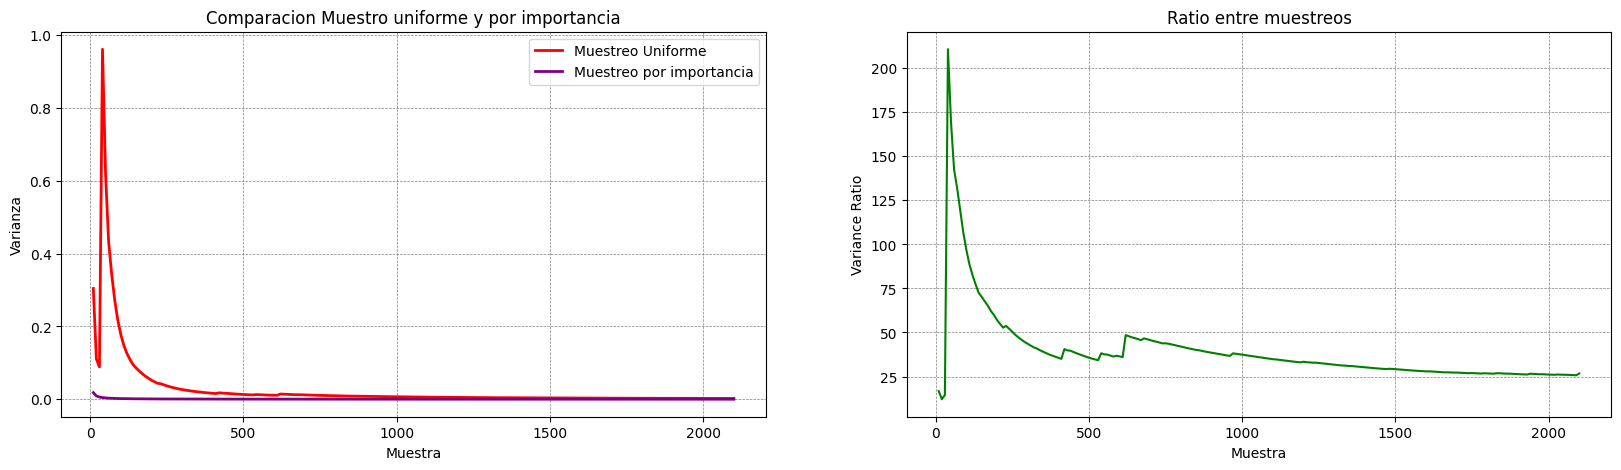

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

file_IS0 = "variance/cootr_unif_t0_2101.csv"
frame, y_IS0 = read_file(file_IS0)
file_IS1 = "variance/cootr_import_t0_2114.csv"
_, y_IS1 = read_file(file_IS1)

y_IS1 = y_IS1[:len(y_IS0)]
frame = frame[:len(y_IS0)]
ratio = y_IS0/y_IS1

# # IMPORTANCE SAMPLING
# axes[0][0].set_title("Muestreo por importancia")
# axes[0][0].grid(color='gray', linestyle='--', linewidth=0.5)
# axes[0][0].plot(frame, y_IS1, color="purple", lw=2.0, label="Varianza")
# axes[0][0].set_xlabel("Muestra")
# axes[0][0].set_ylabel("Varianza")
# axes[0][0].legend()
# # UNIFORM SAMPLING
# axes[1][0].set_title("Muestreo uniforme")
# axes[1][0].grid(color='gray', linestyle='--', linewidth=0.5)
# axes[1][0].plot(frame, y_IS0, color="red", lw=2.0, label="Varianza")
# axes[1][0].set_xlabel("Muestra")
# axes[1][0].set_ylabel("Varianza")
# axes[1][0].legend()
# BOTH TOGETHER
axes[0].set_title("Comparacion Muestro uniforme y por importancia")
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)
axes[0].plot(frame, y_IS0, color="red", lw=2.0, label="Muestreo Uniforme")
axes[0].plot(frame, y_IS1, color="purple", lw=2.0, label="Muestreo por importancia")
axes[0].set_xlabel("Muestra")
axes[0].set_ylabel("Varianza")
axes[0].legend()
# RATIO
axes[1].set_title("Ratio entre muestreos")
axes[1].plot(frame, ratio, color="g", lw=1.5)
axes[1].set_xlabel("Muestra")
axes[1].set_ylabel("Variance Ratio")
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)

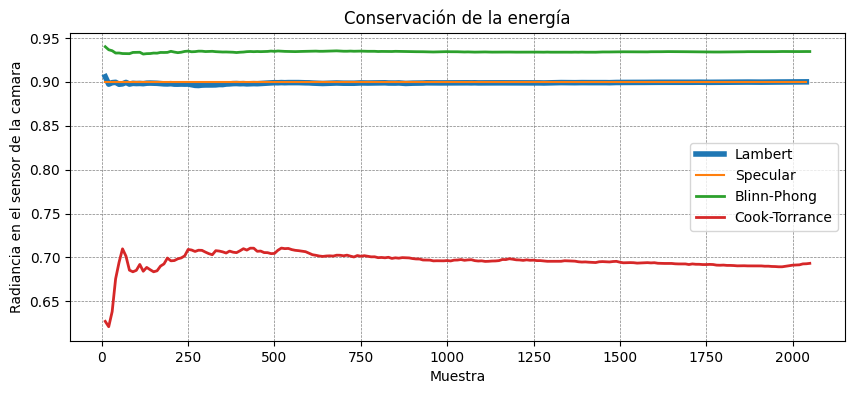

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))

t_l, en_l = read_file("mean_color/lambert_energy_t0_2041.csv")
t_s, en_s = read_file("mean_color/specular_energy_t0_2046.csv")
t_b, en_b = read_file("mean_color/blph_energy_t0_2052.csv")
t_c, en_c = read_file("mean_color/cootr_energy_t0_2051.csv")

# IMPORTANCE SAMPLING
axes.set_title("Conservación de la energía")
axes.grid(color='gray', linestyle='--', linewidth=0.5)
axes.plot(t_l, en_l, lw=4.0, label="Lambert")
axes.plot(t_s, en_s, lw=1.5, label="Specular")
axes.plot(t_b, en_b, lw=2.0, label="Blinn-Phong")
axes.plot(t_c, en_c, lw=2.0, label="Cook-Torrance")
axes.set_xlabel("Muestra")
axes.set_ylabel("Radiancia en el sensor de la camara")
axes.legend()

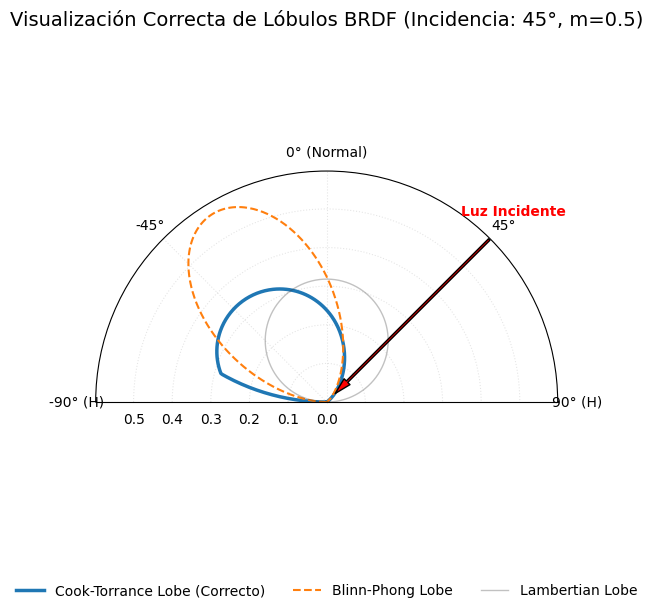

In [67]:
# LOBES
import numpy as np
import matplotlib.pyplot as plt

def plot_brdf_lobes_static(incident_angle_deg, roughness_m, shininess_a, n_index, s_l, s_bp, s_ct):
    """Visualización correcta de lóbulos de BRDF con tus fórmulas."""
    # Convertir a radianes y preparar rango de salida
    I = np.radians(incident_angle_deg)
    t = np.linspace(-np.pi/2, np.pi/2, 500) # Ángulos de salida

    # Precalculos necesarios
    cos_i = np.cos(I)
    cos_t = np.cos(t)
    
    # --- Vectores y Ángulos (Simplificación 2D) ---
    theta_h = (t + I) / 2.0
    cos_theta_h = np.cos(theta_h)
    theta_hv = np.abs(t - I) / 2.0
    c_t = np.cos(theta_hv)
    
    # --- Distribución Beckmann D(t) de tu fórmula ---
    # Con clip numérico para estabilidad
    tan_th = np.tan(theta_h)
    term_d1 = 1.0 / (np.pi * roughness_m**2 * (cos_theta_h**4 + 1e-8))
    D = term_d1 * np.exp(-(tan_th/roughness_m)**2)
    
    # --- Atenuación Geométrica G(t) de tu fórmula ---
    term_g1 = (2 * cos_theta_h * cos_t) / (c_t + 1e-8)
    term_g2 = (2 * cos_theta_h * cos_i) / (c_t + 1e-8)
    G = np.minimum(1.0, np.minimum(term_g1, term_g2))
    G = np.clip(G, 0.0, 1.0) # Estabilidad
    
    # --- Fresnel Completo F(t) de tu fórmula ---
    g_square = np.clip(n_index**2 + c_t**2 - 1.0, 0.0, None)
    g = np.sqrt(g_square)
    term_f1 = (g - c_t)**2 / (g + c_t + 1e-8)**2
    term_f2 = 1.0 + ((c_t * (g + c_t) - 1.0)**2 / (c_t * (g - c_t) + 1.0 + 1e-8)**2)
    F = 0.5 * term_f1 * term_f2
    
    # --- Lóbulo de Radiancia Cook-Torrance (para visualización) ---
    # El divisor cos_t en f_CT se CANCELA con el cos_t final de la radiancia
    lobe_CT = (F * D * G) / (4 * cos_i + 1e-8) * s_ct

    # --- Lóbulo Blinn-Phong (Normalización de energía correcta para Blinn-Phong) ---
    # f_BP = ((a+8)/(8*pi)) * cos_h^a (Normalización de energía estable)
    # Usando la normalización más común para visualización estable
    f_BP_norm = ((shininess_a + 8) / (8 * np.pi)) * (cos_theta_h**shininess_a)
    lobe_BP = f_BP_norm * cos_t * s_bp

    # --- Lóbulo Lambertiano (Difuso) ---
    f_L = 1.0 / np.pi
    lobe_L = f_L * cos_t * s_l

    # --- Gráfica Polar ---
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(10, 6))
    
    # Graficar los lóbulos de radiancia
    ax.plot(t, lobe_CT, label='Cook-Torrance Lobe (Correcto)', linewidth=2.5, color='#1f77b4') # Azul
    ax.plot(t, lobe_BP, label='Blinn-Phong Lobe', linestyle='--', linewidth=1.5, color='#ff7f0e') # Naranja
    ax.plot(t, lobe_L, label='Lambertian Lobe', alpha=0.3, color='#333333', linewidth=1) # Gris
    
    # Dibujar flecha de incidencia (flecha roja)
    ax.annotate('', xy=(I, 0), xytext=(I, max(lobe_CT.max(), lobe_BP.max()) * 1.1),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=6))
    ax.text(I, max(lobe_CT.max(), lobe_BP.max())*1.2, 'Luz Incidente', color='red', ha='center', fontweight='bold')
    
    # Decoraciones de la gráfica polar
    ax.set_thetamin(-90)
    ax.set_thetamax(90)
    ax.set_theta_zero_location("N") # Normal es arriba (0 grados)
    ax.set_theta_direction(-1) # Ángulos positivos a la derecha
    
    # Ajustar los ticks para mostrar 0, 45, 90 grados
    ax.set_thetagrids([-90, -45, 0, 45, 90], labels=['-90° (H)', '-45°', '0° (Normal)', '45°', '90° (H)'])
    ax.grid(True, which='major', linestyle=':', color='black', alpha=0.1)
    
    # Título y leyenda
    plt.title(f"Visualización Correcta de Lóbulos BRDF (Incidencia: {incident_angle_deg}°, m={roughness_m})", fontsize=14, y=1.05)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=10)
    plt.show()

# --- Ejecución de la visualización ---
plot_brdf_lobes_static(incident_angle_deg=45, roughness_m=0.5, shininess_a=10, n_index=15, s_l=1.0, s_bp=1.0, s_ct=1.0)